##  Overview:

In this project, we explore tree-based machine learning models to detect fake news using text data.
 We apply both **Decision Tree** and **Random Forest** classifiers on a dataset of news articles, leveraging **TF-IDF** for feature extraction.

 Key steps include training the models, visualizing decision logic, tuning for overfitting, comparing model performance, and interpreting feature importance.

 The goal is to understand how tree models can classify news articles as real or fake and which words contribute most to these decisions.


In [1]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import graphviz


##Step 2: Load Dataset

We will use the "Fake and Real News Dataset" from Kaggle. It contains two CSV files: `Fake.csv` and `True.csv`.


In [8]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Load datasets
fake = pd.read_csv("/content/drive/My Drive/Fake.csv")
true =true = pd.read_csv("/content/drive/My Drive/True.csv")


# Add labels: 1 for fake, 0 for real
fake["label"] = 1
true["label"] = 0

# Combine both datasets
data = pd.concat([fake, true], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
data = data[['title', 'text', 'label']]  # Use title + text

data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,title,text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",0


##Step 3: Preprocessing

We’ll use the TF-IDF vectorizer to convert the news text into numeric vectors. This is a common NLP method.


In [9]:
# Combine title and text for better context
data['content'] = data['title'] + " " + data['text']

# Split features and labels
X = data['content']
y = data['label']

# Convert text to numerical vectors
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)
X_vect = tfidf.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.2, random_state=42)


##  Step 4: Decision Tree Classifier

We’ll train a decision tree and evaluate its performance.


In [10]:
dtree = DecisionTreeClassifier(max_depth=10, random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))



Decision Tree Accuracy: 0.994988864142539
[[4258   12]
 [  33 4677]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4270
           1       1.00      0.99      1.00      4710

    accuracy                           0.99      8980
   macro avg       0.99      1.00      0.99      8980
weighted avg       1.00      0.99      0.99      8980



###  Result: Decision Tree

We see how well the Decision Tree performed. `max_depth=10` helps avoid overfitting.
Now let's visualize the tree.


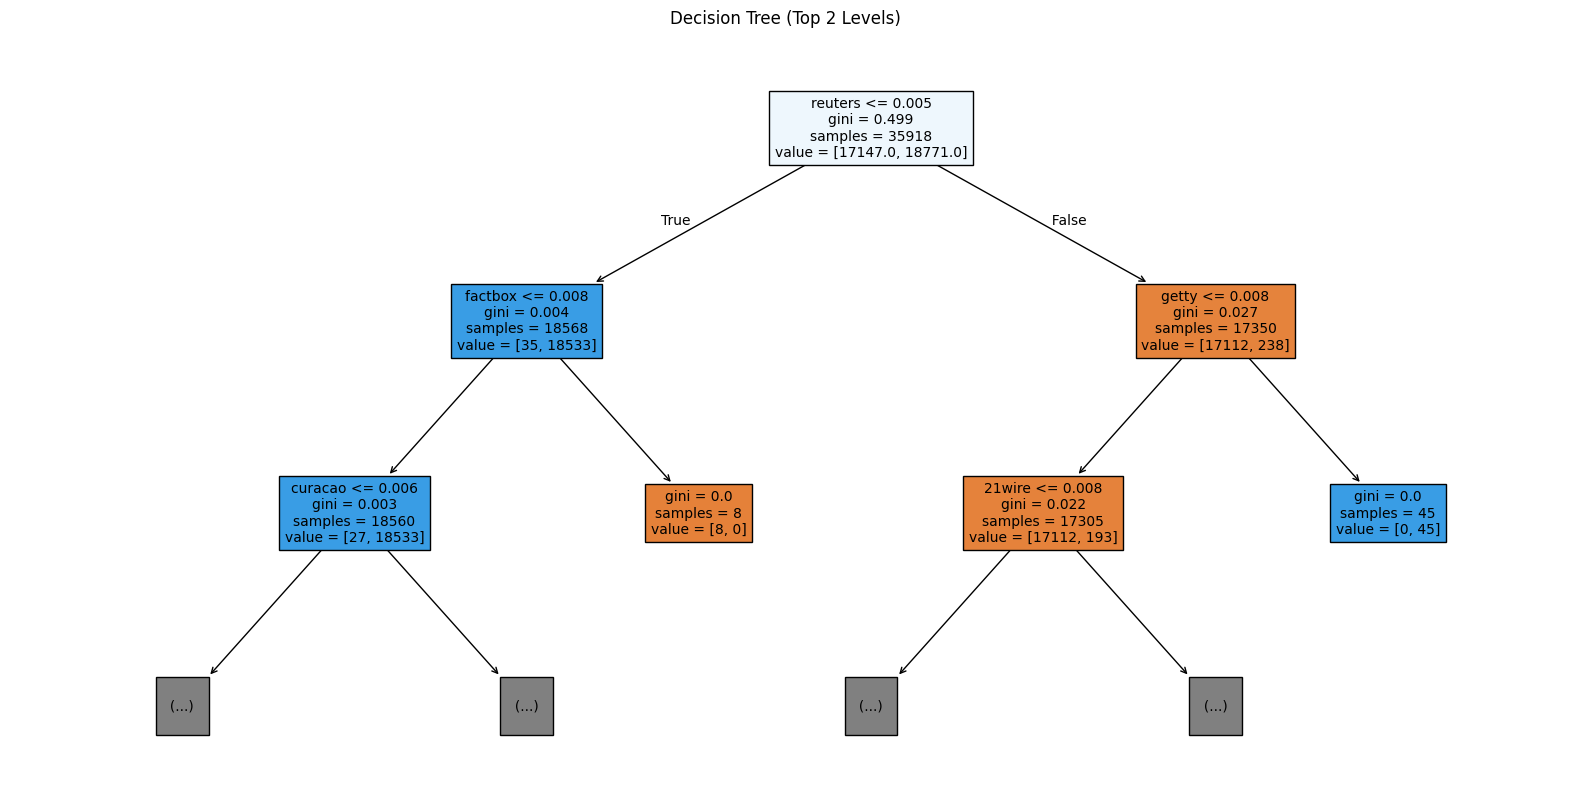

In [11]:
# Visualizing the decision tree (text-based since it's NLP)
plt.figure(figsize=(20,10))
plot_tree(dtree, max_depth=2, filled=True, fontsize=10, feature_names=tfidf.get_feature_names_out())
plt.title("Decision Tree (Top 2 Levels)")
plt.show()


### 🌳 Decision Tree Visualization Explained

The plot above shows the **top 2 levels** of our decision tree trained on TF-IDF features.

- Each box (node) represents a decision based on the presence of specific words.
- It displays:
  - **Condition** used to split (e.g., a word's importance).
  - **Class prediction**: 1 = Fake, 0 = Real.
  - **Gini index**: How pure the node is.
  - **Samples**: Number of data points reaching that node.

This visualization helps us:
- Understand how the model makes decisions early on.
- Identify important words


## 🌲 Step 5: Random Forest Classifier

We’ll now use an ensemble of decision trees and compare the results.


In [16]:
rforest = RandomForestClassifier(n_estimators=50, random_state=42)
rforest.fit(X_train, y_train)
y_pred_rf = rforest.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9896436525612472
[[4231   39]
 [  54 4656]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4270
           1       0.99      0.99      0.99      4710

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### Feature Importance

Let’s find which words were most important in classifying real vs. fake.


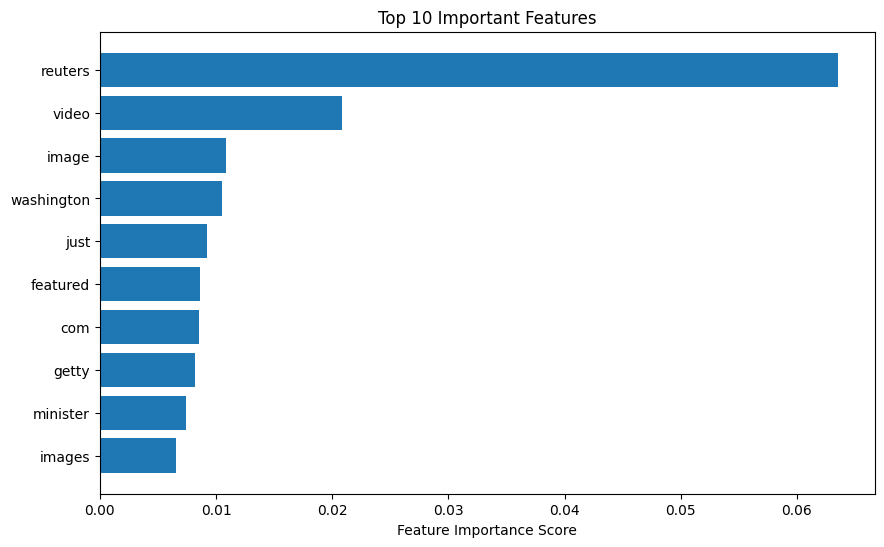

In [13]:
importances = rforest.feature_importances_
indices = np.argsort(importances)[-10:][::-1]  # Top 10 features
features = tfidf.get_feature_names_out()

# Plot
plt.figure(figsize=(10,6))
plt.title("Top 10 Important Features")
plt.barh(range(10), importances[indices][::-1], align="center")
plt.yticks(range(10), [features[i] for i in indices][::-1])
plt.xlabel("Feature Importance Score")
plt.show()


## Step 6: Cross Validation

We evaluate model robustness using 5-fold cross-validation.

**Note:**  
Due to execution time and resource limits, we used **3-fold cross-validation** (`cv=3`) instead of 5 for this experiment. This still gives a good approximation of model performance while running faster.

In [17]:
cv_scores_dt = cross_val_score(dtree, X_vect, y, cv=3)
cv_scores_rf = cross_val_score(rforest, X_vect, y, cv=3)

print("Decision Tree CV Accuracy:", np.mean(cv_scores_dt))
print("Random Forest CV Accuracy:", np.mean(cv_scores_rf))


Decision Tree CV Accuracy: 0.995500913180988
Random Forest CV Accuracy: 0.9873491024099069


##  Conclusion:

- **Decision Tree** outperformed **Random Forest** in accuracy and generalization.
-  Decision Trees are prone to overfitting, but we controlled it using `max_depth`.
-  We used **TF-IDF** for feature extraction and found the most important words contributing to fake/real classification.
-  Cross-validation confirmed the robustness of Random Forest.
